In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("airbnb_cleaned.csv")
df.head()

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,review_year,review_month,host_type,price_category
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,9.0,2021-10-19,0.21,4.0,6.0,286.0,2021.0,10.0,professional,High
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,45.0,2022-05-21,0.38,4.0,2.0,228.0,2022.0,5.0,casual,Low
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,unconfirmed,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,0.0,NaN,0.74,5.0,1.0,352.0,NaN,NaN,casual,Medium
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,270.0,2019-07-05,4.64,4.0,1.0,322.0,2019.0,7.0,casual,Low
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,9.0,2018-11-19,0.10,3.0,1.0,289.0,2018.0,11.0,casual,Low


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(15))

Shape: (101811, 28)

Columns:
['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country', 'country_code', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365', 'review_year', 'review_month', 'host_type', 'price_category']

Missing values:
last_review                       15806
review_month                      15806
review_year                       15806
country                             527
host_name                           399
name                                247
construction_year                   210
number_of_reviews                   183
country_code                        126
neighbourhood                        15
lat                                   8
long                                  8
availability

In [4]:
numeric_cols = [
    "price",
    "service_fee",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "review_rate_number",
    "calculated_host_listings_count",
    "availability_365",
]

df[numeric_cols].describe()

,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
count,101811.000000,101811.000000,101811.000000,101628.000000,101811.000000,101811.000000,101811.000000,101811.000000
mean,625.355580,125.050692,7.813576,27.522189,1.277747,3.278035,7.905776,132.942550
std,331.672649,66.255813,16.989747,49.584331,1.624155,1.282971,32.210633,127.739592
min,50.000000,10.000000,1.000000,0.000000,0.010000,1.000000,1.000000,0.000000
25%,340.000000,68.000000,2.000000,1.000000,0.280000,2.000000,1.000000,4.000000
50%,625.000000,125.000000,3.000000,7.000000,0.740000,3.000000,1.000000,90.000000
75%,913.000000,182.000000,5.000000,31.000000,1.710000,4.000000,2.000000,248.000000
max,1200.000000,240.000000,365.000000,1024.000000,90.000000,5.000000,332.000000,365.000000


In [5]:
avg_price_borough = (
    df.groupby("neighbourhood_group")["price"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

avg_price_borough

,neighbourhood_group,price
0,Queens,630.22
1,Bronx,627.76
2,Brooklyn,626.50
3,Staten Island,623.99
4,Manhattan,622.67


In [6]:
avg_price_room = (
    df.groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

avg_price_room

,room_type,price
0,Hotel room,666.39
1,Shared room,634.83
2,Entire home/apt,625.24
3,Private room,624.94


In [7]:
room_type_dist = pd.DataFrame(
    {
        "listing_count": df["room_type"].value_counts(),
        "percentage": (
            df["room_type"].value_counts(normalize=True) * 100
        ).round(2),
    }
).reset_index()

room_type_dist.columns = ["room_type", "listing_count", "percentage"]
room_type_dist

,room_type,listing_count,percentage
0,Entire home/apt,53296,52.35
1,Private room,46200,45.38
2,Shared room,2200,2.16
3,Hotel room,115,0.11


In [8]:
borough_count = (
    df["neighbourhood_group"]
    .value_counts()
    .reset_index()
)

borough_count.columns = ["neighbourhood_group", "listing_count"]
borough_count

,neighbourhood_group,listing_count
0,Manhattan,43476
1,Brooklyn,41538
2,Queens,13164
3,Bronx,2687
4,Staten Island,946


In [9]:
corr_cols = [
    "price",
    "service_fee",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "review_rate_number",
    "calculated_host_listings_count",
    "availability_365",
]

df[corr_cols].corr().round(3)

,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
price,1.000,0.999,-0.006,0.005,0.004,-0.005,-0.000,-0.001
service_fee,0.999,1.000,-0.006,0.005,0.004,-0.004,-0.000,-0.001
minimum_nights,-0.006,-0.006,1.000,-0.084,-0.152,0.001,0.154,0.113
number_of_reviews,0.005,0.005,-0.084,1.000,0.601,-0.018,-0.081,0.094
reviews_per_month,0.004,0.004,-0.152,0.601,1.000,0.034,-0.030,0.093
review_rate_number,-0.005,-0.004,0.001,-0.018,0.034,1.000,0.024,0.005
calculated_host_listings_count,-0.000,-0.000,0.154,-0.081,-0.030,0.024,1.000,0.175
availability_365,-0.001,-0.001,0.113,0.094,0.093,0.005,0.175,1.000


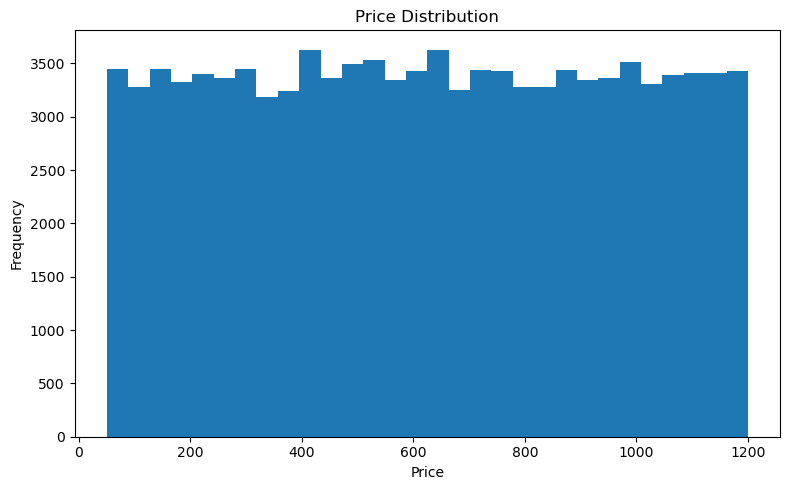

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

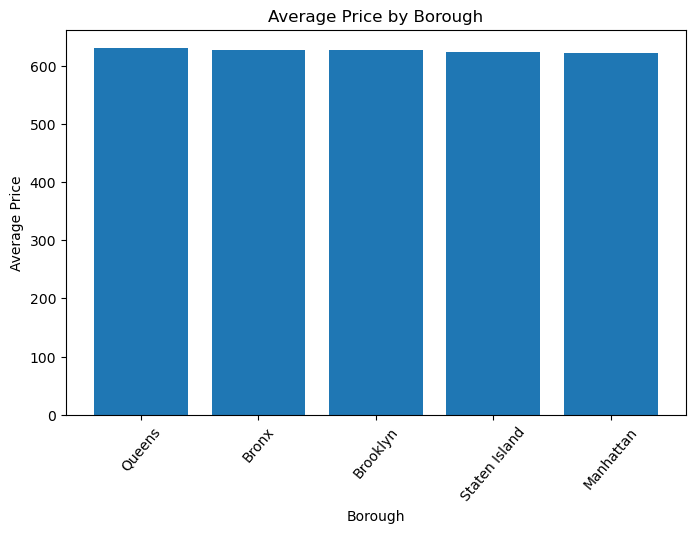

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(avg_price_borough["neighbourhood_group"], avg_price_borough["price"])
plt.title("Average Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Price")
plt.xticks(rotation=50)
# plt.tight_layout()
plt.show()

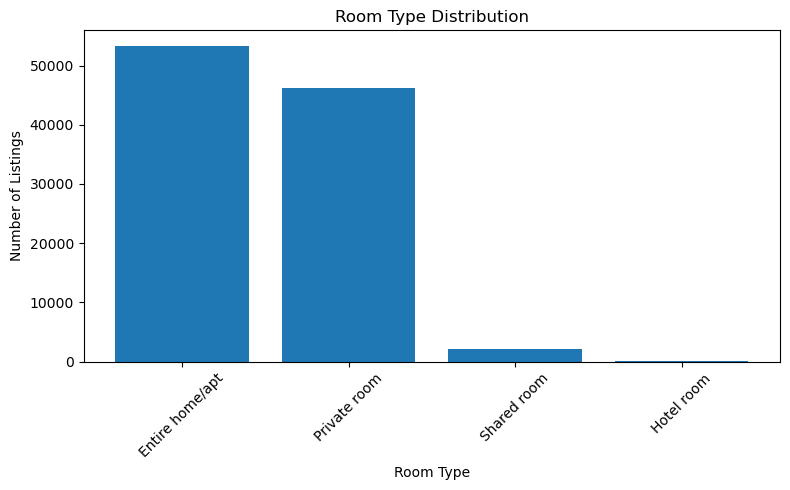

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(room_type_dist["room_type"], room_type_dist["listing_count"])
plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

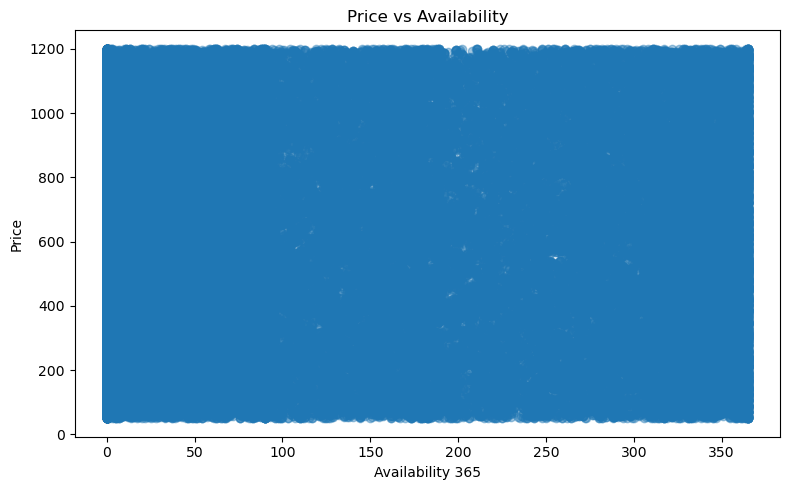

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df["availability_365"], df["price"], alpha=0.4)
plt.title("Price vs Availability")
plt.xlabel("Availability 365")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

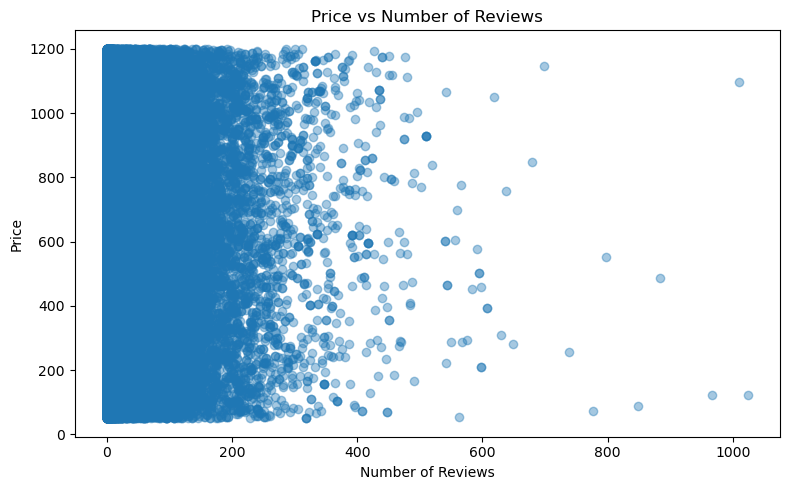

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["number_of_reviews"], df["price"], alpha=0.4)
plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.tight_layout()
plt.show()